
# This notebook evaluates how three preprocessing features affect model performance:
# - F1: Segmentation
# - F2: Filtering
# - F3: Normalization
# 
# Both within-subject and leave-one-subject-out (LOSO) cross‑validation are performed.
# Results are saved as CSV, confusion matrices, and boxplots.


# 1. Imports and Global Settings


In [1]:
import sys
import os
import json
import itertools
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path  # Исправляет ошибку импорта
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, iirnotch, resample

data_path = '/kaggle/input/datasets/skmrel/am-nn-28-03'
scripts_path = '/kaggle/input/datasets/skmrel/utilsskmrel'

if scripts_path not in sys.path:
    sys.path.append(scripts_path)
# Import dataset building logic
from create_dataset_upd_v2 import build_dataset_local
# Import evaluation functions and model architecture
from first_model_eval import (
    run_within_subject_kfold,
    run_train9_val1_test1_subject_kfold5,
    aggregate_results,
    aggregate_train9_val1_test1_results,
    summarize_confusions,
    plot_confusion_matrix,
    set_seed
)

/kaggle/input/datasets/skmrel/utilsskmrel/first_model_eval.py:475: SyntaxWarning: invalid escape sequence '\ '
  - val subjects выбираются из eligible \ {test_subj} (могут повторяться между фолдами)


In [2]:
# Paths and constants
METADATA_PATH = "/kaggle/input/datasets/skmrel/am-nn-28-03/dataset_metadata.json"      
RECORDINGS_ROOT = "/kaggle/input/datasets/skmrel/am-nn-28-03"     

# Use only three subjects for faster ablation (train / val / test for LOSO)
TARGET_SUBJECTS = ['M5', 'C', 'A']

BASE_OUT_DIR = "ablation_reports"
WITHIN_DIR = os.path.join(BASE_OUT_DIR, "within")
LOSO_DIR = os.path.join(BASE_OUT_DIR, "loso")

os.makedirs(WITHIN_DIR, exist_ok=True)
os.makedirs(LOSO_DIR, exist_ok=True)

# Model parameters (same as in first_model_eval.py / cnn_transformer.py)
MODEL_KWARGS = dict(in_ch=8, n_classes=10, d_model=64, stride_cnn=8, k_cnn=21)

# Storage for results across configurations
all_fold_metrics = []
summary_table = []

In [3]:
# ## 2. Helper Function: Filter Dataset by Subjects
def filter_dataset_by_subjects(ds, keep_subjects):
    """Return a copy of the dataset containing only specified subjects."""
    mask = np.isin(ds['subject'], keep_subjects)
    return {
        'emg': ds['emg'][mask],
        'x': ds['x'][mask],
        'y': ds['y'][mask],
        'target': ds['target'][mask],
        'subject': ds['subject'][mask]
    }

In [4]:
# ## 3. Main Ablation Loop (All 8 Combinations)

feature_combinations = list(itertools.product([False, True], repeat=3))
print(f"Starting feature ablation study ({len(feature_combinations)} configurations).")
print(feature_combinations)

Starting feature ablation study (8 configurations).
[(False, False, False), (False, False, True), (False, True, False), (False, True, True), (True, False, False), (True, False, True), (True, True, False), (True, True, True)]


In [5]:
for (f1, f2, f3) in feature_combinations:
    config_name = f"F1_{int(f1)}_F2_{int(f2)}_F3_{int(f3)}"
    print(f"\nProcessing configuration: {config_name} | F1(Seg)={f1}, F2(Filt)={f2}, F3(Norm)={f3}")
    
    # -----------------------------------------------------------------
    # Build dataset with current preprocessing flags
    # -----------------------------------------------------------------
    print("Building dataset...")
    full_ds = build_dataset_local(
        metadata_json_path=METADATA_PATH,
        recordings_root=RECORDINGS_ROOT,
        use_f1=f1, use_f2=f2, use_f3=f3,
        target_length=2500
    )
    ds = filter_dataset_by_subjects(full_ds, TARGET_SUBJECTS)
    print(f"Dataset ready. Total samples: {len(ds['target'])}")

    # -----------------------------------------------------------------
    # Within‑subject evaluation (5‑fold cross‑validation)
    # -----------------------------------------------------------------
    print("Running within‑subject evaluation...")
    res_w, conf_mats_w, _ = run_within_subject_kfold(
        ds, subject_list=TARGET_SUBJECTS,
        x_key="emg", y_key="target",
        n_splits=5, base_seed=42, seeds=(42,),
        batch_size=64, val_batch_size=128, epochs=50,
        patience=15, model_kwargs=MODEL_KWARGS
    )
    
    df_w, _, _, overall_w = aggregate_results(res_w)
    df_w['Config'] = config_name
    df_w['Phase'] = 'Within-Subject'
    all_fold_metrics.append(df_w)
    
    # Save confusion matrix for within‑subject
    cm_w_total = summarize_confusions(conf_mats_w, seed=42)
    fig_w, ax_w = plot_confusion_matrix(
        cm_w_total, 
        title=f"Within CM | {config_name}",
        savepath=os.path.join(WITHIN_DIR, f"cm_within_{config_name}.png")
    )
    plt.close(fig_w)

    # -----------------------------------------------------------------
    # LOSO evaluation (leave‑one‑subject‑out)
    # -----------------------------------------------------------------
    print("Running LOSO evaluation...")
    res_l, conf_mats_l, _ = run_train9_val1_test1_subject_kfold5(
        ds, exclude_holdout_subject=("NONE"), 
        n_folds=len(TARGET_SUBJECTS), 
        n_val_subjects=1,
        seeds=(42,),
        x_key="emg", y_key="target",
        batch_size=64, val_batch_size=128, test_batch_size=256,
        epochs=50, patience=15, model_kwargs=MODEL_KWARGS
    )
    
    df_l, _, _, overall_l = aggregate_train9_val1_test1_results(res_l)
    df_l['Config'] = config_name
    df_l['Phase'] = 'LOSO'
    all_fold_metrics.append(df_l)
    
    # Save confusion matrix for LOSO (test folds only)
    cm_l_total = np.zeros((10, 10), dtype=np.int64)
    for (seed, fold, split, subj), cm in conf_mats_l.items():
        if split == "test" and seed == 42:
            cm_l_total += cm
    
    fig_l, ax_l = plot_confusion_matrix(
        cm_l_total, 
        title=f"LOSO CM | {config_name}",
        savepath=os.path.join(LOSO_DIR, f"cm_loso_{config_name}.png")
    )
    plt.close(fig_l)

    # -----------------------------------------------------------------
    # Store overall metrics for final summary table
    # -----------------------------------------------------------------
    summary_table.append({
        "Config": config_name,
        "F1 (Seg)": f1, "F2 (Filt)": f2, "F3 (Norm)": f3,
        "Within Acc": overall_w["acc_mean_over_seeds"],
        "Within F1": overall_w["f1_mean_over_seeds"],
        "LOSO Acc": overall_l["acc_mean_over_seeds"],
        "LOSO F1": overall_l["f1_mean_over_seeds"]
    })



Processing configuration: F1_0_F2_0_F3_0 | F1(Seg)=False, F2(Filt)=False, F3(Norm)=False
Building dataset...
Successfully processed file: export1_13Nov07.mat
Successfully processed file: export1_15Nov07.mat
Successfully processed file: export1_30Nov07.mat
Successfully processed file: export1_19Dec07.mat
Successfully processed file: export1_20Dec07.mat
Successfully processed file: export1_21Dec07.mat
Successfully processed file: export1_2Jan08.mat
Successfully processed file: export1_3Jan08.mat
Successfully processed file: export1_7Jan08.mat
Successfully processed file: export1_15Jan08.mat
Successfully processed file: export1_24Jan08.mat
Dataset ready. Total samples: 1511
Running within‑subject evaluation...

===== SEED 42 =====

--- Subject M5 ---

[Subject M5] Fold 1/5 | train=440 val=110


/kaggle/input/datasets/skmrel/utilsskmrel/cnn_transformer.py:253: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 001 | train loss 2.3295 acc 0.070 | val loss 2.3091 acc 0.100
Epoch 002 | train loss 2.3058 acc 0.089 | val loss 2.2983 acc 0.100
Epoch 003 | train loss 2.2759 acc 0.125 | val loss 2.2588 acc 0.173
Epoch 004 | train loss 2.2397 acc 0.193 | val loss 2.2117 acc 0.200
Epoch 005 | train loss 2.1829 acc 0.198 | val loss 2.1489 acc 0.209
Epoch 006 | train loss 2.1101 acc 0.268 | val loss 2.0905 acc 0.300
Epoch 007 | train loss 2.0366 acc 0.300 | val loss 2.0049 acc 0.309
Epoch 008 | train loss 1.9555 acc 0.309 | val loss 1.9125 acc 0.309
Epoch 009 | train loss 1.8340 acc 0.414 | val loss 1.7966 acc 0.364
Epoch 010 | train loss 1.7880 acc 0.425 | val loss 1.7455 acc 0.382
Epoch 011 | train loss 1.6432 acc 0.493 | val loss 1.6507 acc 0.391
Epoch 012 | train loss 1.5650 acc 0.514 | val loss 1.6032 acc 0.391
Epoch 013 | train loss 1.5245 acc 0.516 | val loss 1.5473 acc 0.391
Epoch 014 | train loss 1.4183 acc 0.543 | val loss 1.5261 acc 0.391
Epoch 015 | train loss 1.3971 acc 0.523 | val lo

/kaggle/input/datasets/skmrel/utilsskmrel/cnn_transformer.py:253: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 001 | train loss 2.3322 acc 0.105 | val loss 2.3077 acc 0.091
Epoch 002 | train loss 2.3028 acc 0.123 | val loss 2.2789 acc 0.164
Epoch 003 | train loss 2.2568 acc 0.150 | val loss 2.1787 acc 0.182
Epoch 004 | train loss 2.1985 acc 0.177 | val loss 2.0541 acc 0.291
Epoch 005 | train loss 2.0968 acc 0.227 | val loss 1.9484 acc 0.291
Epoch 006 | train loss 2.0318 acc 0.277 | val loss 1.8849 acc 0.255
Epoch 007 | train loss 1.9575 acc 0.309 | val loss 1.8474 acc 0.264
Epoch 008 | train loss 1.9334 acc 0.318 | val loss 1.8055 acc 0.318
Epoch 009 | train loss 1.8615 acc 0.364 | val loss 1.7747 acc 0.364
Epoch 010 | train loss 1.8493 acc 0.382 | val loss 1.7142 acc 0.391
Epoch 011 | train loss 1.7705 acc 0.423 | val loss 1.6731 acc 0.391
Epoch 012 | train loss 1.7465 acc 0.445 | val loss 1.6309 acc 0.409
Epoch 013 | train loss 1.6986 acc 0.425 | val loss 1.5884 acc 0.464
Epoch 014 | train loss 1.6409 acc 0.470 | val loss 1.5493 acc 0.445
Epoch 015 | train loss 1.5699 acc 0.511 | val lo

...

Epoch 001 | train loss 2.3223 acc 0.113 | val loss 2.3351 acc 0.105
Epoch 002 | train loss 2.2176 acc 0.198 | val loss 2.3815 acc 0.098
Epoch 003 | train loss 2.1272 acc 0.222 | val loss 2.4451 acc 0.104
Epoch 004 | train loss 2.0115 acc 0.290 | val loss 2.5957 acc 0.182
Epoch 005 | train loss 1.9587 acc 0.345 | val loss 2.7758 acc 0.155
Epoch 006 | train loss 1.8944 acc 0.348 | val loss 2.8713 acc 0.175
Epoch 007 | train loss 1.8214 acc 0.371 | val loss 2.9495 acc 0.158
Epoch 008 | train loss 1.7619 acc 0.409 | val loss 3.0407 acc 0.151
Epoch 009 | train loss 1.7815 acc 0.377 | val loss 3.0426 acc 0.167
Epoch 010 | train loss 1.6998 acc 0.450 | val loss 3.1433 acc 0.149
Epoch 011 | train loss 1.6938 acc 0.443 | val loss 3.0799 acc 0.165
Epoch 012 | train loss 1.6529 acc 0.443 | val loss 3.1942 acc 0.158
Epoch 013 | train loss 1.6435 acc 0.478 | val loss 3.2352 acc 0.162
Epoch 014 | train loss 1.6865 acc 0.497 | val loss 3.3443 acc 0.153
Epoch 015 | train loss 1.5853 acc 0.522 | val lo

/kaggle/input/datasets/skmrel/utilsskmrel/cnn_transformer.py:253: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 001 | train loss 2.3512 acc 0.098 | val loss 2.3166 acc 0.104
Epoch 002 | train loss 2.2658 acc 0.156 | val loss 2.3120 acc 0.167
Epoch 003 | train loss 2.2000 acc 0.239 | val loss 2.3848 acc 0.110
Epoch 004 | train loss 2.1468 acc 0.245 | val loss 2.4097 acc 0.106
Epoch 005 | train loss 2.0625 acc 0.273 | val loss 2.4595 acc 0.102
Epoch 006 | train loss 2.0168 acc 0.303 | val loss 2.6827 acc 0.096
Epoch 007 | train loss 1.9803 acc 0.330 | val loss 2.5618 acc 0.120
Epoch 008 | train loss 1.9045 acc 0.362 | val loss 2.7118 acc 0.100
Epoch 009 | train loss 1.8594 acc 0.367 | val loss 2.7502 acc 0.100
Epoch 010 | train loss 1.8629 acc 0.397 | val loss 2.6915 acc 0.114
Epoch 011 | train loss 1.7850 acc 0.463 | val loss 2.8279 acc 0.098
Epoch 012 | train loss 1.7461 acc 0.409 | val loss 2.8197 acc 0.104
Epoch 013 | train loss 1.6930 acc 0.473 | val loss 2.7554 acc 0.112
Epoch 014 | train loss 1.6780 acc 0.471 | val loss 2.7844 acc 0.120
Epoch 015 | train loss 1.6448 acc 0.490 | val lo

/kaggle/input/datasets/skmrel/utilsskmrel/cnn_transformer.py:253: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 001 | train loss 2.3288 acc 0.098 | val loss 2.2858 acc 0.089
Epoch 002 | train loss 2.2400 acc 0.132 | val loss 2.2454 acc 0.111
Epoch 003 | train loss 2.1320 acc 0.280 | val loss 2.2063 acc 0.122
Epoch 004 | train loss 2.0087 acc 0.276 | val loss 2.2019 acc 0.167
Epoch 005 | train loss 1.9239 acc 0.297 | val loss 2.2711 acc 0.176
Epoch 006 | train loss 1.7786 acc 0.451 | val loss 2.2553 acc 0.144
Epoch 007 | train loss 1.7199 acc 0.390 | val loss 2.3068 acc 0.147
Epoch 008 | train loss 1.7457 acc 0.400 | val loss 2.4268 acc 0.149
Epoch 009 | train loss 1.6083 acc 0.447 | val loss 2.3903 acc 0.180
Epoch 010 | train loss 1.5576 acc 0.506 | val loss 2.4524 acc 0.173
Epoch 011 | train loss 1.5652 acc 0.494 | val loss 2.4747 acc 0.173
Epoch 012 | train loss 1.5184 acc 0.504 | val loss 2.5829 acc 0.176
Epoch 013 | train loss 1.5383 acc 0.500 | val loss 2.6296 acc 0.178
Epoch 014 | train loss 1.4536 acc 0.545 | val loss 2.7226 acc 0.176
Epoch 015 | train loss 1.4659 acc 0.533 | val lo


Ablation study results (summary table):
        Config  F1 (Seg)  F2 (Filt)  F3 (Norm)  Within Acc  Within F1  LOSO Acc  LOSO F1
F1_0_F2_0_F3_0     False      False      False    0.682317   0.663700  0.093726 0.067081
F1_0_F2_0_F3_1     False      False       True    0.706727   0.691955  0.099963 0.038180
F1_0_F2_1_F3_0     False       True      False    0.690013   0.668138  0.115263 0.057232
F1_0_F2_1_F3_1     False       True       True    0.687119   0.667507  0.085367 0.042270
F1_1_F2_0_F3_0      True      False      False    0.770730   0.762596  0.140527 0.056894
F1_1_F2_0_F3_1      True      False       True    0.761165   0.749282  0.184335 0.101610
F1_1_F2_1_F3_0      True       True      False    0.768855   0.759921  0.121981 0.045912
F1_1_F2_1_F3_1      True       True       True    0.769645   0.762318  0.186346 0.091579


/tmp/ipykernel_57/699644073.py:28: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


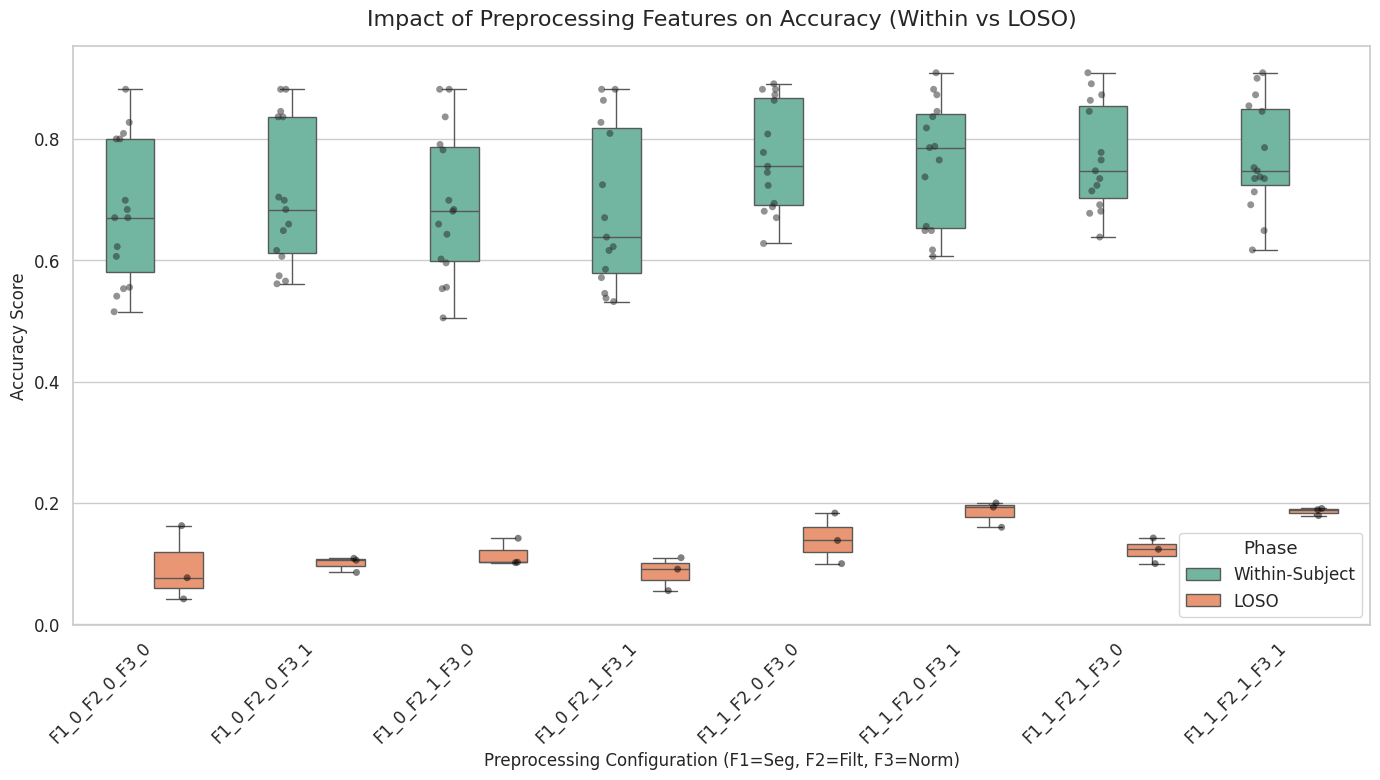


All outputs saved to 'ablation_reports' directory (CSV, confusion matrices, boxplot).


In [7]:
#combining results and boxplors drawings
df_summary = pd.DataFrame(summary_table)
df_summary.to_csv(os.path.join(BASE_OUT_DIR, "ablation_summary.csv"), index=False)

print("\nAblation study results (summary table):")
print(df_summary.to_string(index=False))

# Prepare data for boxplots
df_all_folds = pd.concat(all_fold_metrics, ignore_index=True)
# Harmonise column name: within uses 'val_acc', LOSO uses 'test_acc'
df_all_folds['Accuracy'] = df_all_folds['test_acc'].combine_first(df_all_folds['val_acc'])

# Create boxplot
sns.set_theme(style="whitegrid", font_scale=1.1)
fig, ax = plt.subplots(figsize=(14, 8))

sns.boxplot(
    data=df_all_folds, 
    x="Config", 
    y="Accuracy", 
    hue="Phase", 
    palette="Set2",
    width=0.6,
    ax=ax
)

# Overlay individual fold points
sns.stripplot(
    data=df_all_folds, 
    x="Config", 
    y="Accuracy", 
    hue="Phase", 
    dodge=True, 
    alpha=0.5, 
    color="black",
    ax=ax,
    legend=False
)

ax.set_title("Impact of Preprocessing Features on Accuracy (Within vs LOSO)", pad=15, fontsize=16)
ax.set_xlabel("Preprocessing Configuration (F1=Seg, F2=Filt, F3=Norm)", fontsize=12)
ax.set_ylabel("Accuracy Score", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

fig.savefig(os.path.join(BASE_OUT_DIR, "feature_ablation_boxplots.png"), dpi=300)
plt.show()

print(f"\nAll outputs saved to '{BASE_OUT_DIR}' directory (CSV, confusion matrices, boxplot).")